**말라리아 분류**

In [1]:
import numpy as np
import pandas as pd
import os, random 
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

2026-06-12 07:17:17.397793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781248637.602182      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781248637.663513      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781248638.184819      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781248638.184875      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781248638.184878      58 computation_placer.cc:177] computation placer alr

In [2]:
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    break

/kaggle/input


In [3]:
# 데이터 불러오기

SEED = 42
BASE = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
parasitized_count = len(os.listdir(os.path.join(BASE, "Parasitized")))
uninfected_count = len(os.listdir(os.path.join(BASE, "Uninfected")))

print("Parasitized:", parasitized_count)
print("Uninfected:", uninfected_count)
print(class_names)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.


I0000 00:00:1781248660.897199      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781248660.904182      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Parasitized: 13780
Uninfected: 13780
['Parasitized', 'Uninfected']


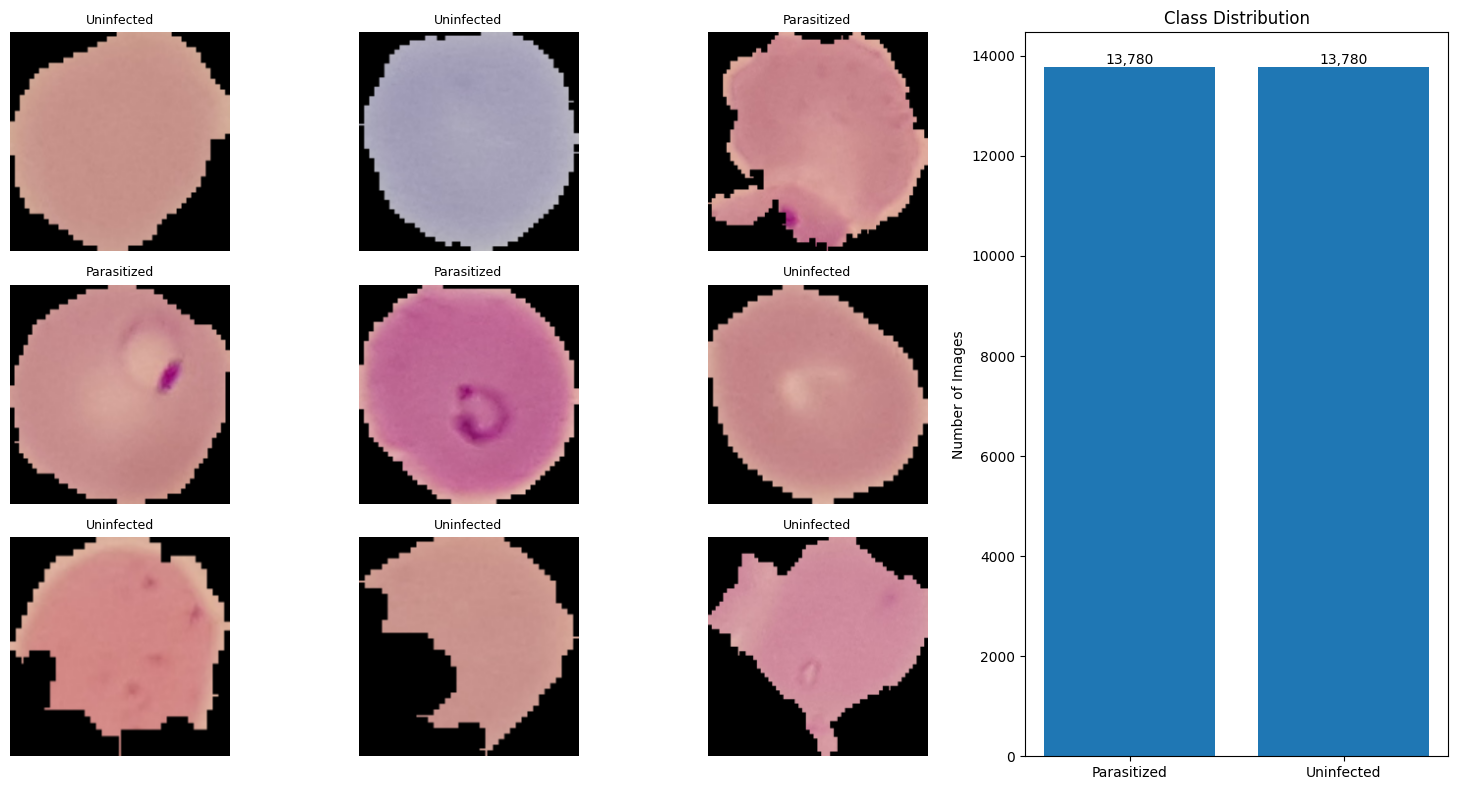

In [4]:
# 샘플 이미지, 분포 확인

fig = plt.figure(figsize=(15,8))

# 이미지
left_gs = fig.add_gridspec(
    3, 4,
    width_ratios=[1,1,1,1.5]
)

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = fig.add_subplot(left_gs[i//3, i%3])
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.set_title(
            train_ds.class_names[labels[i].numpy()],
            fontsize=9
        )
        ax.axis("off")

# 분포 그래프
ax_bar = fig.add_subplot(left_gs[:,3])
classes = ["Parasitized", "Uninfected"]
counts = [parasitized_count, uninfected_count]
bars = ax_bar.bar(classes, counts)

ax_bar.set_title("Class Distribution")
ax_bar.set_ylabel("Number of Images")

for bar in bars:
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [5]:
# 정규화
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 확인
for images, labels in train_ds.take(1):
    print(images.numpy().min())
    print(images.numpy().max())

# 속도 최적화

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

0.0
0.9180501


In [6]:
# 모델 생성

SimpleCNN = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(2)
])

SimpleCNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,130 (98.36 MB)

 Trainable params: 25,784,130 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 컴파일
SimpleCNN.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [8]:
# 학습 함수

def train_model(model, train_ds, val_ds, model_name="Model", epochs=10):
    print(f"===== Training {model_name} =====")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

    print(f"===== {model_name} Training Finished =====")

    return history

In [9]:
# 평가 함수

def evaluate_model(model, val_ds, class_names, model_name="Model"):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"===== {model_name} Evaluation =====")
    print(f"Accuracy: {accuracy:.4f}")
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    return y_true, y_pred

In [10]:
# 혼동행렬

def plot_confusion_matrix(y_true, y_pred, class_names, model_name="Model", save=False):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"{model_name} Confusion Matrix")

    if save:
        plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")

    plt.show()

    return cm

In [11]:
# 바교 학습곡선

def compare_history(history1, history2, name1="Model1", name2="Model2"):
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax[0].plot(history1.history['accuracy'], marker='o', label=f'{name1} Train')
    ax[0].plot(history1.history['val_accuracy'], marker='s', label=f'{name1} Val')
    ax[0].plot(history2.history['accuracy'], marker='o', linestyle='--', label=f'{name2} Train')
    ax[0].plot(history2.history['val_accuracy'], marker='s', linestyle='--', label=f'{name2} Val')

    ax[0].set_title('Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    # Loss
    ax[1].plot(history1.history['loss'], marker='o', label=f'{name1} Train')
    ax[1].plot(history1.history['val_loss'], marker='s', label=f'{name1} Val')
    ax[1].plot(history2.history['loss'], marker='o', linestyle='--', label=f'{name2} Train')
    ax[1].plot(history2.history['val_loss'], marker='s', linestyle='--', label=f'{name2} Val')

    ax[1].set_title('Loss Comparison')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

학습시작

===== Training SimpleCNN =====
Epoch 1/10


I0000 00:00:1781248670.844969     136 service.cc:152] XLA service 0x7ddec80040c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781248670.845017     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781248670.845022     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781248671.454098     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/689 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.4948 - loss: 3.7428

I0000 00:00:1781248676.569663     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.8559 - loss: 0.3415 - val_accuracy: 0.9419 - val_loss: 0.1802
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9454 - loss: 0.1770 - val_accuracy: 0.9537 - val_loss: 0.1489
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9541 - loss: 0.1427 - val_accuracy: 0.9555 - val_loss: 0.1430
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9614 - loss: 0.1139 - val_accuracy: 0.9517 - val_loss: 0.1536
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9640 - loss: 0.1054 - val_accuracy: 0.9436 - val_loss: 0.2172
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9761 - loss: 0.0681 - val_accuracy: 0.9445 - val_loss: 0.2391
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9833 - loss: 0.0505 - val_accuracy: 0.9443 - val_loss: 0.2777
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.9883 - loss: 0.0370 - val_accurac

<Figure size 600x500 with 0 Axes>

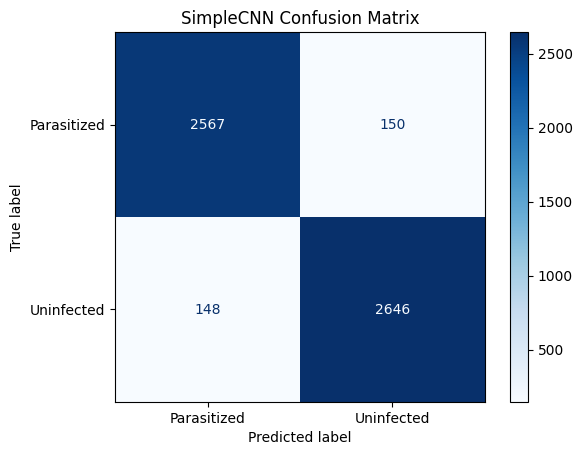

In [12]:
# 학습
history_simple = train_model(
    SimpleCNN,
    train_ds,
    val_ds,
    model_name="SimpleCNN",
    epochs=10
)

# 평가
y_true_simple, y_pred_simple = evaluate_model(
    SimpleCNN,
    val_ds,
    class_names,
    model_name="SimpleCNN"
)

# 혼동행렬
cm_simple = plot_confusion_matrix(
    y_true_simple,
    y_pred_simple,
    class_names,
    model_name="SimpleCNN",
    save=True
)

In [13]:
# Augmentation 

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="DataAugmentation")

In [15]:
# 적용 모델 v2
AugCNN = models.Sequential([
    
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(2)
])

AugCNN.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


===== Training AugCNN =====
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.8117 - loss: 0.4119 - val_accuracy: 0.9372 - val_loss: 0.1923
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9438 - loss: 0.1794 - val_accuracy: 0.9508 - val_loss: 0.1605
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.9491 - loss: 0.1610 - val_accuracy: 0.9461 - val_loss: 0.1672
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.9536 - loss: 0.1501 - val_accuracy: 0.9479 - val_loss: 0.1507
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.9560 - loss: 0.1408 - val_accuracy: 0.9521 - val_loss: 0.1449
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9565 - loss: 0.1421 - val_accuracy: 0.9508 - val_loss: 0.1411
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9575 - loss: 0.1337 - val_accuracy: 0.9577 - val_loss: 0.1321
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accura

<Figure size 600x500 with 0 Axes>

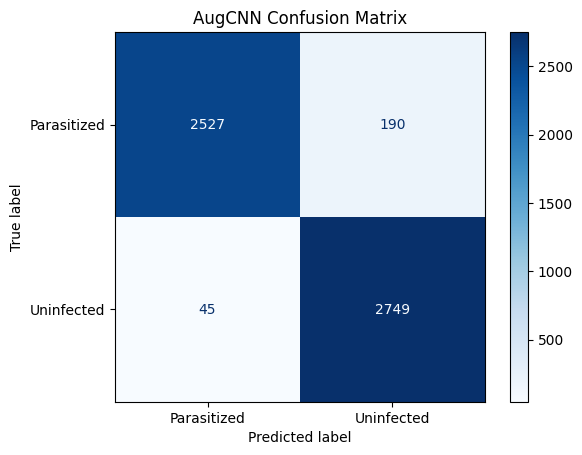

In [16]:
# v2 학습 및 시각화

history_aug = train_model(
    AugCNN,
    train_ds,
    val_ds,
    model_name="AugCNN",
    epochs=10
)

y_true_aug, y_pred_aug = evaluate_model(
    AugCNN,
    val_ds,
    class_names,
    model_name="AugCNN"
)

cm_aug = plot_confusion_matrix(
    y_true_aug,
    y_pred_aug,
    class_names,
    model_name="AugCNN",
    save=True
)

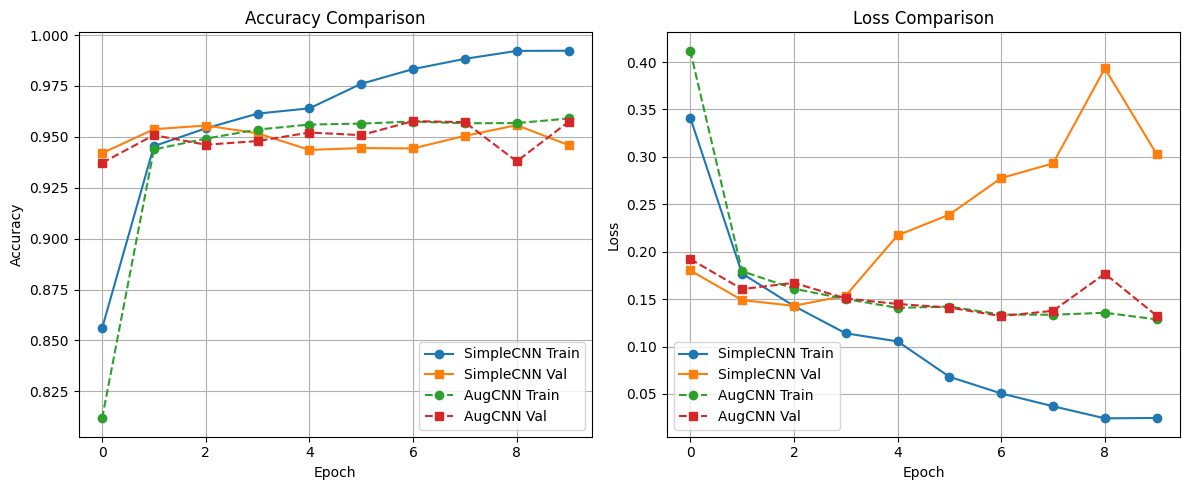

In [17]:
compare_history(history_simple,history_aug,"SimpleCNN","AugCNN")

In [18]:
# Dropout

DropoutCNN = models.Sequential([

    data_augmentation,

    # Block 1
    layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),

    # Classifier
    layers.Flatten(),
    layers.Dense(256,activation='relu'),

    # ⭐ Dropout 추가
    layers.Dropout(0.3),
    layers.Dense(2)
])

# 컴파일 

DropoutCNN.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


===== Training DropoutCNN =====
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.5707 - loss: 0.7032 - val_accuracy: 0.6277 - val_loss: 0.6402
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.6201 - loss: 0.6564 - val_accuracy: 0.6772 - val_loss: 0.6169
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.8630 - loss: 0.3790 - val_accuracy: 0.9338 - val_loss: 0.2108
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9373 - loss: 0.1991 - val_accuracy: 0.9378 - val_loss: 0.1905
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9471 - loss: 0.1653 - val_accuracy: 0.9516 - val_loss: 0.1477
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9505 - loss: 0.1586 - val_accuracy: 0.9559 - val_loss: 0.1375
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.9530 - loss: 0.1511 - val_accuracy: 0.9546 - val_loss: 0.1366
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - ac

<Figure size 600x500 with 0 Axes>

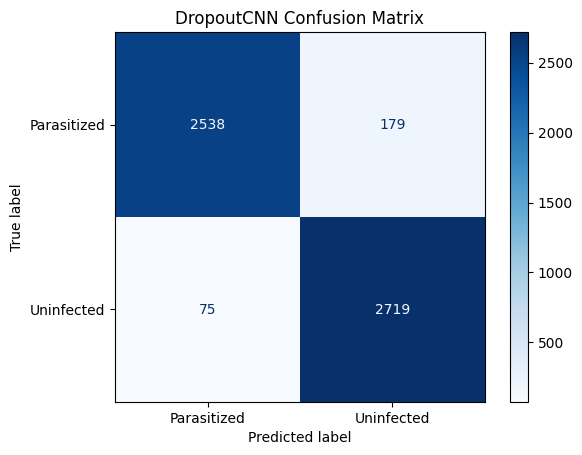

In [19]:
# V3 학습 및 시각화

history_dropout = train_model(
    DropoutCNN,
    train_ds,
    val_ds,
    model_name="DropoutCNN",
    epochs=10
)

y_true_dropout, y_pred_dropout = evaluate_model(
    DropoutCNN,
    val_ds,
    class_names,
    model_name="DropoutCNN"
)

cm_dropout = plot_confusion_matrix(
    y_true_dropout,
    y_pred_dropout,
    class_names,
    model_name="DropoutCNN",
    save=True
)

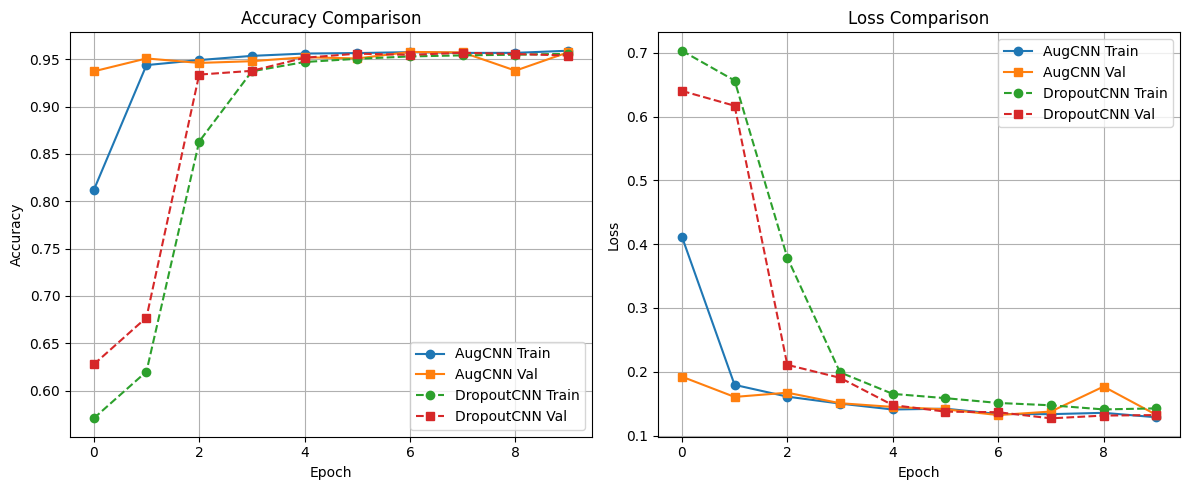

In [23]:
compare_history(history_aug,history_dropout,"AugCNN","DropoutCNN")

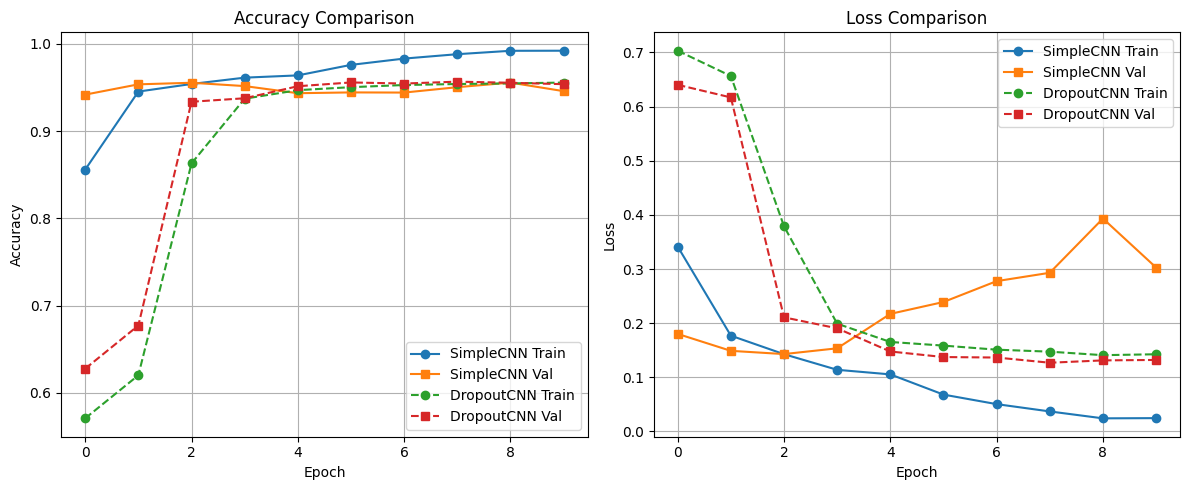

In [24]:
compare_history(history_simple,history_dropout,"SimpleCNN","DropoutCNN")